In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/MyDrive/GCP_Assignment
!ls

/content/drive/MyDrive/GCP_Assignment
predictions.json  src  test_dataset  train_dataset  weights


In [6]:
!pip install -q albumentations opencv-python tqdm scikit-learn

In [7]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
Tesla T4


In [8]:
%cd src
!ls

/content/drive/MyDrive/GCP_Assignment/src
dataset.py  model.py	 train.py	utils.py
infer.py    __pycache__  transforms.py	visualize.py


In [9]:
!python train.py

Device: cuda
Total usable samples: 996
Train: 796
Validation: 200
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 147MB/s]
Class weights: tensor([1.8685, 1.0127, 0.6769], device='cuda:0')

Starting Training...
Epoch 01/30 | Train Loss: 0.6306 | Val Loss: 0.2574 | Acc: 0.9550 | F1: 0.9493 | PCK@10: 0.0000 | PCK@25: 0.0150 | PCK@50: 0.0400
 -> Saved best loss model
 -> Saved best F1 model
Epoch 02/30 | Train Loss: 0.4535 | Val Loss: 0.2497 | Acc: 0.9800 | F1: 0.9802 | PCK@10: 0.0000 | PCK@25: 0.0150 | PCK@50: 0.0600
 -> Saved best loss model
 -> Saved best F1 model
Epoch 03/30 | Train Loss: 0.4251 | Val Loss: 0.2710 | Acc: 0.9850 | F1: 0.9842 | PCK@10: 0.0000 | PCK@25: 0.0150 | PCK@50: 0.0500
 -> Saved best F1 model
Epoch 04/30 | Train Loss: 0.4215 | Val Loss: 0.1931 | Acc: 0.9950 | F1: 0.9958 | PCK@10: 0.0050 | PCK@25: 0.0200 | PCK@50: 0.0

In [10]:
import shutil

shutil.copy(
    "../weights/best_loss_model.pth",
    "../weights/best_loss_reg5.pth"
)

shutil.copy(
    "../weights/best_f1_model.pth",
    "../weights/best_f1_reg5.pth"
)

shutil.copy(
    "../weights/training_history.csv",
    "../weights/training_history_reg5.csv"
)

print("REG=5 artifacts backed up.")

REG=5 artifacts backed up.


In [11]:
!python infer.py

Running inference on device: cuda
Loaded checkpoint (epoch 18)
Checkpoint F1: 1.0000
Found 300 test images.
Inference: 100% 300/300 [03:40<00:00,  1.36it/s]

Saved predictions to:
../predictions.json
Total predictions: 300


In [12]:
import json

with open("../predictions.json") as f:
    preds = json.load(f)

print("Total predictions:", len(preds))

sample_key = list(preds.keys())[0]

print("\nSample key:")
print(sample_key)

print("\nSample prediction:")
print(preds[sample_key])

Total predictions: 300

Sample key:
231129_CTD/231129_CTD_GDA94/11/DJI_20231129142314_0151.JPG

Sample prediction:
{'mark': {'x': 2201.389892578125, 'y': 1402.3004150390625}, 'verified_shape': 'Cross'}


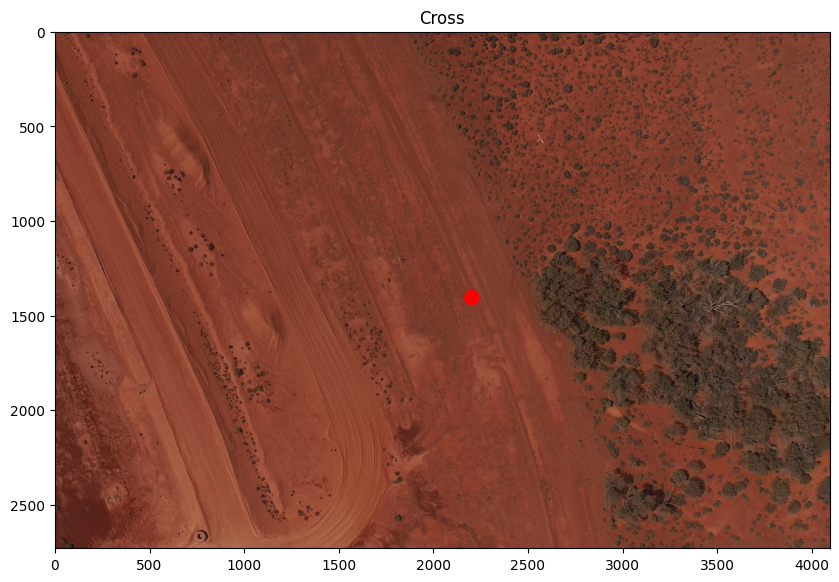

In [13]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(
    "../test_dataset/" + sample_key
)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

x = preds[sample_key]["mark"]["x"]
y = preds[sample_key]["mark"]["y"]

plt.figure(figsize=(10,10))
plt.imshow(img)

plt.scatter(
    [x],
    [y],
    s=100,
    c="red"
)

plt.title(
    preds[sample_key]["verified_shape"]
)

plt.show()

In [14]:
import os

files = [
    "../predictions.json",
    "../weights/best_loss_reg5.pth",
    "../weights/training_history_reg5.csv"
]

for f in files:
    print(
        f,
        "✓" if os.path.exists(f) else "✗"
    )

../predictions.json ✓
../weights/best_loss_reg5.pth ✓
../weights/training_history_reg5.csv ✓
